# Analysis of the Allegheny County Jail Oversight Board Meeting Minutes

- Contributor: Samiha Islam
- AI Acknowledgements: Copilot was used 

## Topic Modeling Analysis

This notebook contains code that performs Topic Modeling Analysis, using BERT, of pre-processed JOB meeting minutes text. 

### Import libraries and lemmatized text data:
If transformers and BERTopic is not already imported, use !pip install transformers and !pip install bertopic

In [136]:
from transformers import AutoTokenizer, AutoModel
import torch
from pathlib import Path
import pickle
import numpy as np
from bertopic import BERTopic

# Load BERT Tokenizer and Model

In [137]:
tokenizer = AutoTokenizer.from_pretrained('bert-base-uncased')
embedding_model = AutoModel.from_pretrained('bert-base-uncased')

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


### Load Documents 
It turns out that BERT works best on raw text, not the lemmatized version. The warden tenure analysis was basically only showing one dominant topic for all 3, and the two exisiting topics were not insightful, even after continuing to remove stopwords, so I'm commenting all code for using preprocessed data out and trying again with raw text files.

In [138]:
BASE = Path("..").resolve()
OUT_DIR = BASE / "Data" / "Text"
path = OUT_DIR / "lemmatized_text.xz"

with open(path, 'rb') as f:
    documents = pickle.load(f)

In [139]:
from pathlib import Path

RAW_DIR = Path("..") / "Data" / "Text"   

raw_docs = []

for path in RAW_DIR.glob("*.txt"):
    with open(path, "r", encoding="utf-8") as f:
        raw_docs.append(f.read())


# Filter stopwords
First, manually define words that are meaningless and came up frequently from the preprocessing for the LDA and n-gram analysis. 

In [140]:
manual_stop_words = [
    # names as found during the n-gram analysis
    'judge court', 'judge joseph', 'judge judge', 'mr .', 'sheriff department',
    'sheriff kevin', 'sheriff office', 'sheriff william', 'warden address',
    'warden administrative', 'warden answer', 'warden chief', 'warden deputy',
    'warden good', 'warden jail', 'warden jason', 'warden judge', 'warden know',
    'warden like', 'warden long', 'warden respond', 'warden staff', 'warden state',
    'warden talk', 'warden think', 'warden update', 'warden want', 'warden warden',
    'warden work', 'warden ms.', 'warden provide', 'warden response', 'warden search',

    # fillers during conversations - should not be meaningful
    'know', 'think', 'want', 'okay', 'thank', 'like',
    'actually', 'thing', 'ask', 'look', 'say', 'yes', 'yeah', 'sure',
    'oh', 'sorry', 'maybe', 'lot', 
    'let', 'bring', 'tell', 'come', 'happen', 'hear',
    'speak', 'try', 'find', 'understand', 'able',
    'way', 'today', 'anybody', 'everybody', 'somebody', 'guy', 'folk',
    'far', 'past', 'long', 'different', 'specific', 'specifically',
    'currently', 'actually', 'forward', 'outside', 'available', 'little',
    'couple', 'ago', 'appreciate', 'mention', 'run', 'add', 'end', 'page',
    
    # some of the single letters are showing up as frequent words
    'e', 't', 's', 'o', 'n', 'r', 'h', 'w', 'c', 'd', 'l', 'g',
    'f', 'p', 'u', 'm', 'y', "'",
    
    # meeting formal words
    'meeting', 'motion', 'second', 'approve', 'adjourn', 'report',
    'member', 'present', 'minute', 'vote', 'board', 'committee',
    'comment', 'public', 'business', 'follow', 'address', 'discussion',
    'record', 'hold', 'begin', 'complete', 'submit', 'review', 'executive', 'president',
    
    # places/locations
    'allegheny', 'county', 'pennsylvania', 'pittsburgh',
    
    # names of specific board members
    'hallam', 'evashavik', 'howsie', 'beasom', 'lazzara', 'brinkman',
    'toma', 'bigley', 'innamorato', 'damick', 'wagner', 'moss',
    'klein', 'perkins', 'williams', 'clark', 'bethany', 'ludwig', 'mcdaniel', 'ron', 'dana', 'chuck', 'doug',
    'larry', 'pofi', 'acchs', 'martoni', 'madarino', 'catanese',
    'phillips', 'donna', 'jo', 'joe', 'orlando', 'harper', 'latoya',
    'mullen', 'fitzgerald', 'asturi', 'carol', 'hertz', 'mike',
    'gilmore', 'marion', 'chelsa', 'william', 'dilucente', '-dilucente', 'cashman',
    'walker', 'corizon', 'wingard', 'trevor', 'defazio', 'korinski',
    'dilucente', 'right', 'talk', 'man', 'hood', 'price', 'griffin', 'officer', 'connor', 'acj', 'mean', 'zak', 'person',
    'visit', 'beth', 'ali', 'kroll', 'davis', 'martin', 'judgeclark', "o'connor", 'kimberly', 'm.', 'gayle', 'elliott',

    # titles, prefixes, and other noticed words/characters with little or no meaning
    '.', '-', 'mr', 'ms', 'mr.', 'ms.', 'dr.', 'dr', 'inmate', 'jail', 'judge', 'warden', 'report', 'oversight', 'board',
    'conference', 'room', 'court', 'honorable', '00', '000', '000incarceratedindividual', '00am', '00o', '00p', '00pm',
    '01', '015', '02', '023', '03', '038', '04', '040', '048', '05', '050', '06', '069',
    'actions', 'mrs', 'following', 'duly', 'unanimously', 'approval', 'agreement', 'share', 'austin', 'party', 'respectfully', 
    'adjournment', 'secretary', 'parole', 'distribute', 'inform', 'mrs.', 'represent',

    # other words that are showing up as frequent but are not meaningful
    'people', 'time', 'work', 'individual', 'question', 'staff', 'month', 'state', 'pm', 'am', 'staff', 'deputy', 'sheriff',
    'new', 'day', 'time', 'program', 'use', 'regard', 'year', 'number', 'p.m.'
]

Add extra stopwords that came up during earlier runs of BERTopic and standardize the formatting so we have a list of clean stop words

In [141]:
clean_stopwords = set()
for w in manual_stop_words:
    w = w.lower().strip()
    if w.isalpha():
        clean_stopwords.add(w)

clean_stopwords = clean_stopwords.union(ENGLISH_STOP_WORDS)

extra_stopwords = {
    "jail", "inmate", "inmates", "warden", "judge", "board", "county",
    "ms", "mr", "mrs", "dr", "hallam", "clark", "evashavik", "howsie",
    "motion", "approve", "meeting", "committee", "public", "comment",
    "report", "services", "oversight", "galvin", "fax", "reporting", "services",
    "stated", "individuals", "representing", "going", "just", "im", "dont", "thats", "youre", 
    "theyre", "did", "make", "just", "ok", "okay", "yeah", "um", "uh", "right", "like", "got", "get",
    "chief", "approved", "seconded", "minutes", "reported",
    "asked", "said", "really", "things", "need", "does", "did", "make",
    "comments", "questions", "job", "facility", "center", "members",
    "population", "community", "going", "just"
}

clean_stopwords = clean_stopwords.union(extra_stopwords)



Convert stopwords to list for CountVectorizer

In [142]:
clean_stopwords = list(clean_stopwords)

Remove additional terms that come up in runs of BERTopic

In [143]:

from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
import re

def clean_minutes(text):
    text = text.lower()
    text = re.sub(r"page \d+ of \d+", " ", text)
    text = re.sub(r"\b\d+\b", " ", text)
    text = re.sub(r"\b\d{1,2}:\d{2}\b", " ", text)
    text = re.sub(r"\b(mr|ms|mrs|dr)\s+[a-z]+\b", " ", text)
    text = re.sub(r"allegheny county jail oversight board", " ", text)
    text = re.sub(r"monthly meeting", " ", text)
    text = re.sub(r"motion to approve", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

clean_docs = [clean_minutes(doc) for doc in raw_docs]


In [144]:
from bertopic import BERTopic
from hdbscan import HDBSCAN
import umap
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(
    stop_words=clean_stopwords,
    max_features=7000,
    ngram_range=(1,2),
    token_pattern=r"(?u)\b[a-zA-Z]{2,}\b",
  )

Set UMAP paramaters

In [145]:
umap_model = umap.UMAP(
    n_neighbors=25,       # more local structure
    n_components=10,      # higher-dimensional space
    min_dist=0.0,         # tightens clusters
    metric='cosine',
    random_state=42
)


Set HDBSCAN parameters

In [146]:
hdbscan_model = HDBSCAN(
    min_cluster_size=5,          # smaller clusters 
    min_samples=1,               # less conservative
    cluster_selection_epsilon=0.1,  # encourages splitting
    metric='euclidean',
    cluster_selection_method='eom'
)


Run BERTopic

In [147]:
topic_model = BERTopic(
    vectorizer_model=vectorizer,
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    nr_topics=None

)

topics, probs = topic_model.fit_transform(clean_docs)
topic_info = topic_model.get_topic_info()
topic_info

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

,Topic,Count,Name,Representation,Representative_Docs
0,-1,4,-1_vaccine_meetings_incarcerated_response,"[vaccine, meetings, incarcerated, response, co...","[, the of the was held on thursday, april , he..."
1,0,73,0_health_mental_goodwill_women,"[health, mental, goodwill, women, wardens, men...","[the of the was held on thursday, april , , in..."
2,1,44,1_medical_incarcerated_oconnor_information,"[medical, incarcerated, oconnor, information, ...",[galvin reporting services - - -- - - (fax) al...
3,2,15,2_incarcerated_health_training_information,"[incarcerated, health, training, information, ...","[job good afternoon, i am judge kim clark. i w..."
4,3,7,3_health_books_covid_tablets,"[health, books, covid, tablets, mental, fund, ...","[the of the was held thursday, august , held a..."
5,4,7,4_incarcerated_regarding_concerned_food,"[incarcerated, regarding, concerned, food, hea...","[the of the , thursday, february , held as a v..."
6,5,6,5_hon_kim berkeley_hon kim_berkeley,"[hon, kim berkeley, hon kim, berkeley, kim, ar...","[| p a g e the of the was held on thursday, fe..."


Check top words and probabilities by topic

In [148]:
for topic_id in topic_info.Topic:
    print(f"\nTopic {topic_id}")
    print(topic_model.get_topic(topic_id))


Topic -1
[('vaccine', 0.030609611570912677), ('meetings', 0.028925787503189457), ('incarcerated', 0.02704645941193713), ('response', 0.02633607878766638), ('covid', 0.024610014420513717), ('health', 0.02143484646477759), ('plan', 0.020898994976474985), ('pandemic', 0.02029252849526711), ('residents', 0.01945515800205161), ('folks', 0.01937783703631848)]

Topic 0
[('health', 0.03131837152687534), ('mental', 0.01785760613895895), ('goodwill', 0.016917446375352665), ('women', 0.01636396817555785), ('wardens', 0.016319407228881595), ('mental health', 0.016082387763637525), ('inquired', 0.015978103187835213), ('controller', 0.015936963934239927), ('offenders', 0.01572493232740931), ('pregnant', 0.0156615832072393)]

Topic 1
[('medical', 0.013915960036818945), ('incarcerated', 0.0134973684587809), ('oconnor', 0.013087775353807621), ('information', 0.011180714714672517), ('mane', 0.010959506007605637), ('health', 0.010576833874440722), ('good', 0.010319118156279086), ('officers', 0.010219113

Visualize top words by topic

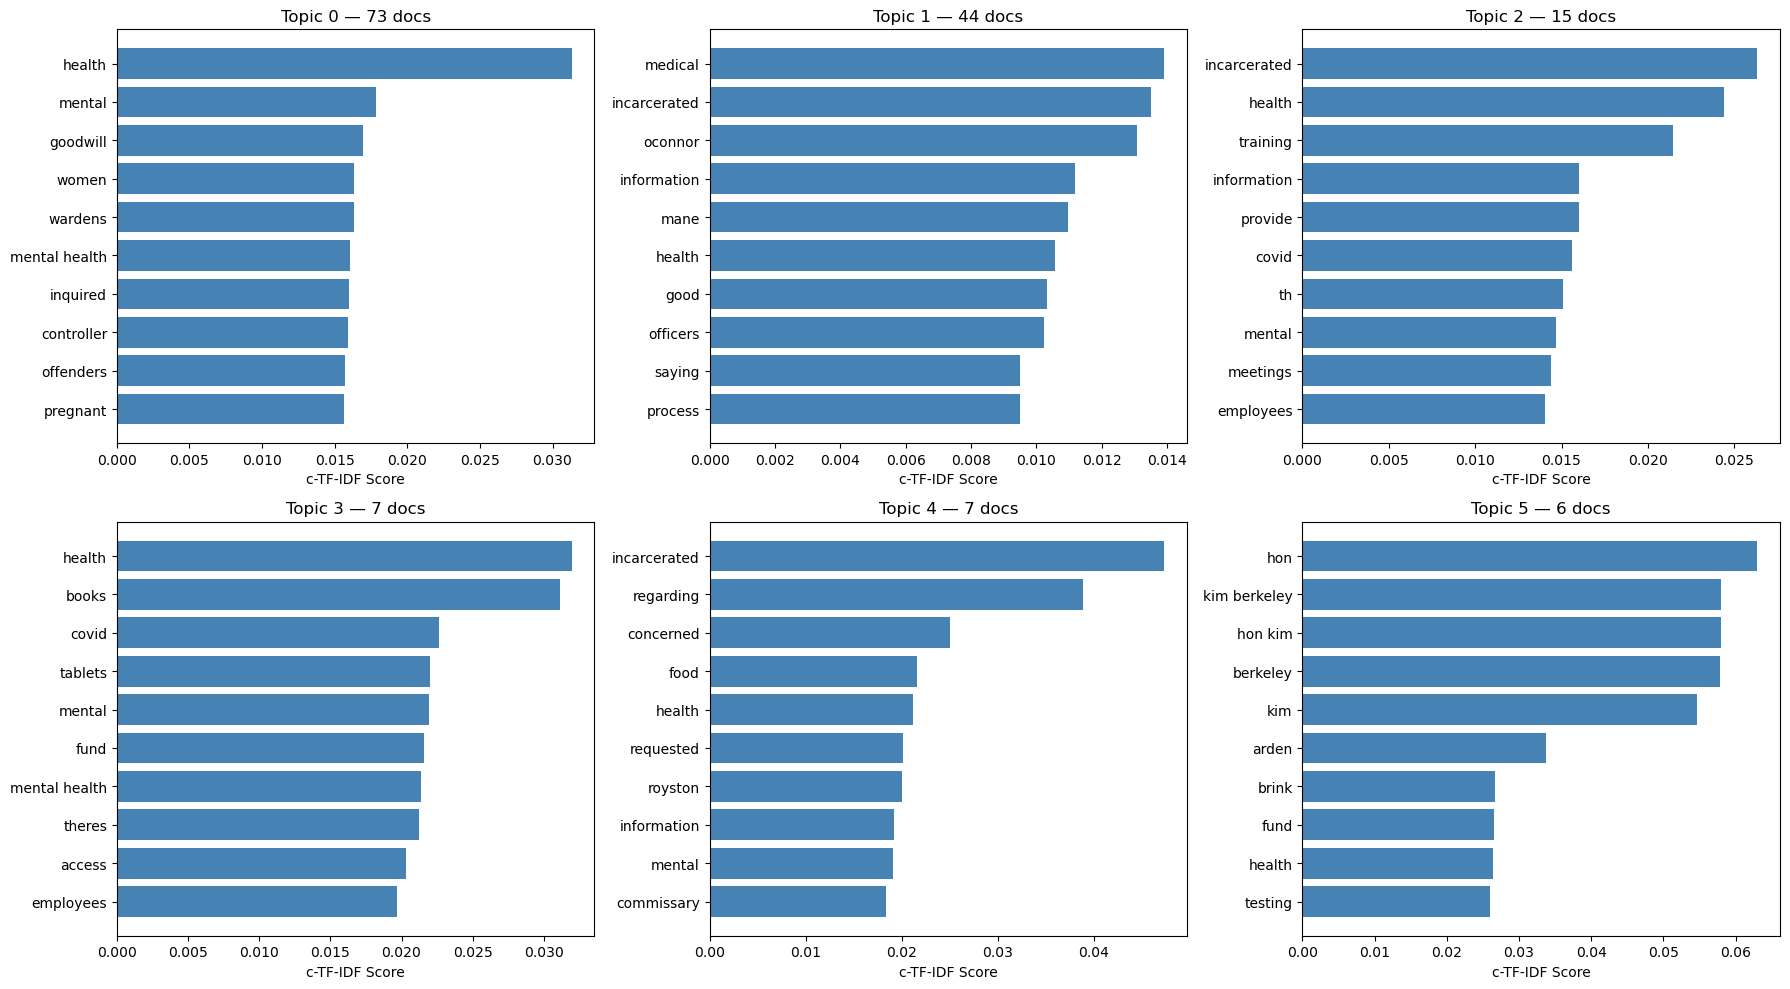

In [ ]:
import matplotlib.pyplot as plt

def plot_topic_panels(topic_model, top_n=10):
    topic_info = topic_model.get_topic_info()
    real_topics = [t for t in topic_info.Topic if t != -1]
    n_topics = len(real_topics)

    # Create panel: 2 rows × 3 columns 
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    axes = axes.flatten()

    for ax, topic_id in zip(axes, real_topics):
        # Get count
        count = topic_info.loc[topic_info['Topic'] == topic_id, 'Count'].values[0]

        # Get words
        words = topic_model.get_topic(topic_id)
        words = words[:top_n]
        labels = [w[0] for w in words]
        scores = [w[1] for w in words]

        # Plot
        ax.barh(labels, scores, color='steelblue')
        ax.invert_yaxis()
        ax.set_title(f"Topic {topic_id} — {count} docs")
        ax.set_xlabel("c-TF-IDF Score")

    for j in range(len(real_topics), len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

# Run it
plot_topic_panels(topic_model, top_n=10)


# View Main Topics Across Years
We want to see what the main topics of discussion are under each warden's tenure 
* Tenure 1: Orlando Harper, September 2012 through September 2023
* Tenure 2: Shane Dady, October 2023 through December 2024
* Tenure 3: Trevor Wingard, January 2025 to present


First, make a dataframe that stores the year and month for each document

In [151]:
import re

def extract_year_month(text):
    # If text is a list of tokens, join it
    if isinstance(text, list):
        text = " ".join(text)

    months = {
        "january": 1, "february": 2, "march": 3, "april": 4,
        "may": 5, "june": 6, "july": 7, "august": 8,
        "september": 9, "october": 10, "november": 11, "december": 12
    }

    year_match = re.search(r"\b(20\d{2})\b", text)
    year = int(year_match.group(1)) if year_match else None

    month_match = re.search(
        r"(january|february|march|april|may|june|july|august|september|october|november|december)",
        text.lower()
    )
    month = months[month_match.group(1)] if month_match else None

    return year, month


In [152]:
year_month = [extract_year_month(doc) for doc in documents]
years = [ym[0] for ym in year_month]
months = [ym[1] for ym in year_month]


In [153]:
import pandas as pd
df = pd.DataFrame({
    "document": documents,
    "topic": topics,
    "year": years,
    "month": months
})

In [154]:
df["year"].max()


2026.0

Define dates for each warden's tenure

In [155]:
tenure_1 = (
    (df["year"] > 2012) & (df["year"] < 2023)
) | (
    (df["year"] == 2012) & (df["month"] >= 9)
) | (
    (df["year"] == 2023) & (df["month"] <= 9)
)

tenure_2 = (
    (df["year"] == 2023) & (df["month"] >= 10)
) | (
    (df["year"] == 2024)
)

tenure_3 = (
    (df["year"] > 2024) 
) 



Assign each document to a tenure

In [156]:
df["period"] = None
df.loc[tenure_1, "period"] = "Harper"
df.loc[tenure_2, "period"] = "Dady"
df.loc[tenure_3, "period"] = "Wingard"

In [157]:
df["period"].value_counts()

period
Harper     118
Dady        17
Wingard     15
Name: count, dtype: int64

Remove topic=-1, as that represents noise

In [158]:
df_clean = df[df["topic"] != -1]


Show topic distributions by warden tenure period

In [159]:
topic_by_period = (
    df_clean
    .groupby(["period", "topic"])
    .size()
    .unstack(fill_value=0)
)

topic_by_period

topic,0,1,2,3,4,5
period,,,,,,
Dady,0,17,0,0,0,0
Harper,71,12,14,7,7,6
Wingard,0,15,0,0,0,0


The majority of documents are in Harper's tenure, as he was in office for over 10 years and the others were in office for less than 2 years. To give a better sense of the distribution, we calculate the percentage of documents in each topic by tenure

In [160]:
topic_by_period_percent = topic_by_period.div(topic_by_period.sum(axis=1), axis=0) * 100

Display topics for the meeting documents in each warden's tenure


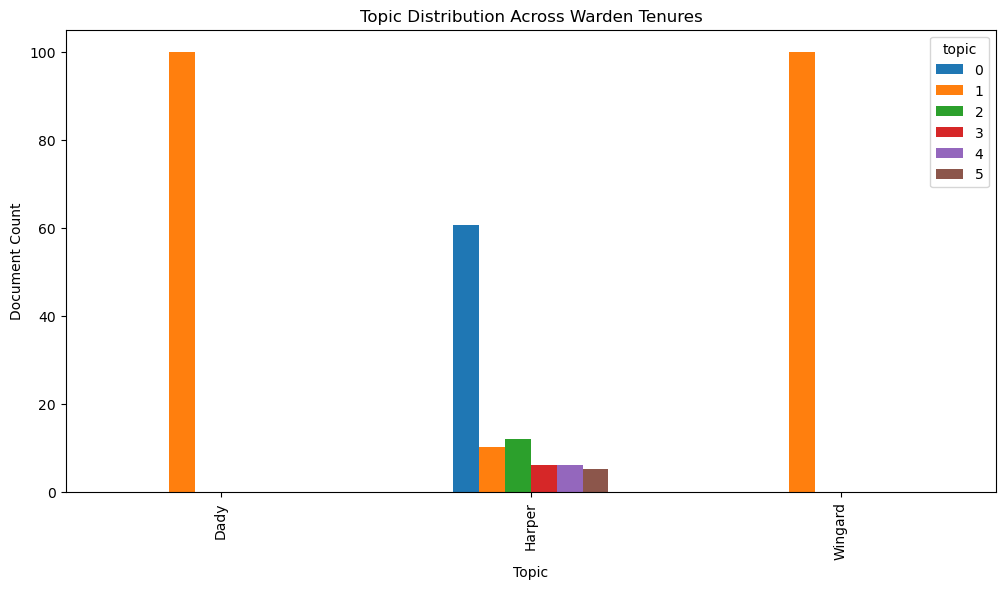

In [161]:
topic_by_period_percent.plot(kind="bar", figsize=(12,6))
plt.title("Topic Distribution Across Warden Tenures")
plt.xlabel("Topic")
plt.ylabel("Document Count")
plt.show()